### Adaptation
Edit the numbers marked `👈` and re-run.

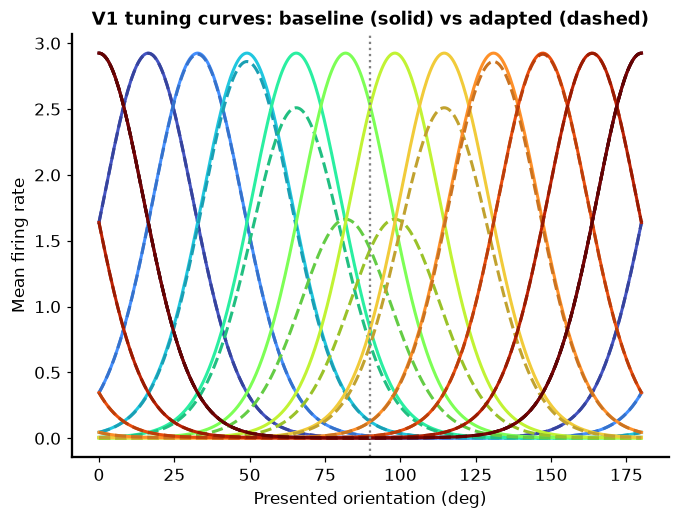

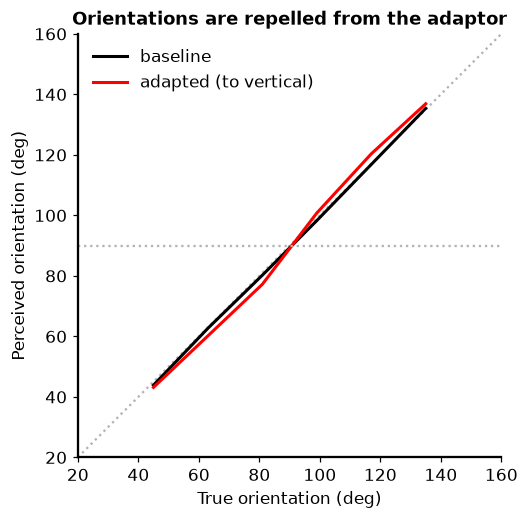

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

from scipy.special import i0
rng = np.random.default_rng()

nneurons = 12
v1mus = np.linspace(0, np.pi, nneurons)
kappa = 3.65            # 👈 tuning width (FWHM ~70 deg, like real V1)
alpha = 0.5             # 👈 adaptation strength
adapt = np.pi / 2       # adapt to vertical

def vm(x, mu):          # von Mises tuning curve (firing rate) over 0-180 deg
    return (1 / (np.pi * i0(kappa))) * np.exp(kappa * np.cos(2 * (x - mu))) * 2

oris = np.linspace(0, np.pi, 360)
fr = np.array([vm(oris, mu) for mu in v1mus])          # baseline tuning, per neuron
fr_adaptor = np.array([vm(adapt, mu) for mu in v1mus]) / fr.max()
fr_adapted = (1 - alpha * fr_adaptor)[:, None] * fr    # adapted tuning

colours = plt.cm.turbo(np.linspace(0, 1, nneurons))
fig, ax = plt.subplots(figsize=(7, 5))
for ni in range(nneurons):
    ax.plot(oris * 180/np.pi, fr[ni], color=colours[ni], lw=2)
    ax.plot(oris * 180/np.pi, fr_adapted[ni], color=colours[ni] * np.array([.8,.8,.8,1]),
            lw=2, ls="--")
ax.axvline(adapt * 180/np.pi, color="0.5", ls=":")
ax.set(xlabel="Presented orientation (deg)", ylabel="Mean firing rate",
       title="V1 tuning curves: baseline (solid) vs adapted (dashed)")
plt.show()

# decode the perceived orientation (maximum a posteriori) before and after adapting
ntest = 6
test_oris = np.linspace(np.pi/4, 3*np.pi/4, ntest)
nsim = 300

def decode(adapted):
    out = np.zeros((nsim, ntest))
    logfr = np.log(fr_adapted if adapted else fr)      # (nneurons, oris)
    for ti, to in enumerate(test_oris):
        post = np.zeros((nsim, oris.size))
        for ni, mu in enumerate(v1mus):
            rate = vm(to, mu) * ((1 - alpha*fr_adaptor[ni]) if adapted else 1.0)
            counts = rng.poisson(rate, nsim)
            post += counts[:, None] * logfr[ni][None, :]
        out[:, ti] = oris[np.argmax(post, axis=1)]
    return out

m0, mA = decode(False), decode(True)

fig, ax = plt.subplots(figsize=(7, 5))
deg = 180/np.pi
ax.plot([20,160],[20,160], "0.7", ls=":")
ax.plot(test_oris*deg, np.median(m0, 0)*deg, "k", lw=2, label="baseline")
ax.plot(test_oris*deg, np.median(mA, 0)*deg, "r", lw=2, label="adapted (to vertical)")
ax.axhline(90, color="0.7", ls=":")
ax.set(xlim=(20,160), ylim=(20,160), xlabel="True orientation (deg)",
       ylabel="Perceived orientation (deg)", title="Orientations are repelled from the adaptor")
ax.set_aspect("equal"); ax.legend(loc="upper left")
plt.show()
